In [8]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [9]:
df = pd.read_csv('customer churn.csv')
df
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#replacing blanks with 0 and as tenure is 0 and no total charges are recorded 

In [11]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df["customerID"].duplicated().sum()

np.int64(0)

In [16]:
def conv(value):
    if value == 1:
        return("yes")
    else:
        return("no")

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

#converted 0 and 1 value of senior citizen to  yes/no to make it easier to understand

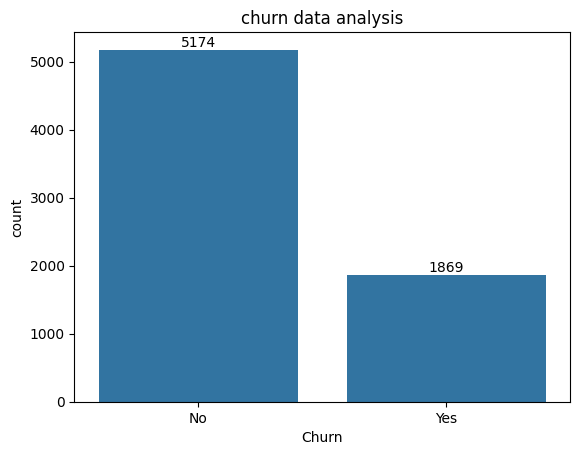

In [37]:
# making bar chart of churn column
ax = sns.countplot(x ='Churn', data = df) 
ax.bar_label(ax.containers[0]) # adding numbers on top of bars
plt.title("count of customers by churn")
plt.show() # displaying the chart

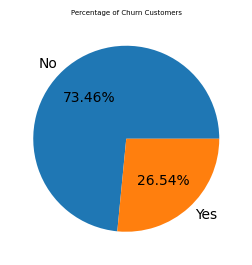

In [127]:
plt.figure(figsize = (3,4)) #for adjusting size of figure
gb = df.groupby("Churn").agg({'Churn':"count"}) #group by and count 
plt.title("Percentage of Churn Customers", fontsize = 10)
plt.pie(gb["Churn"], labels = gb.index, autopct = "%1.2f%%") #for pie chart and labels on it and also for showing percentage 
plt.show() #displays pie chart

#from the given pie chart we can conclude that 26.54% of our customers have churned out. 
#now lets explore the reason behind it

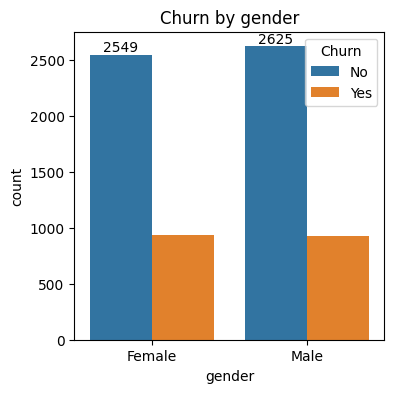

In [57]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x="gender", data = df, hue = ("Churn"))
plt.title("Churn by gender")
ax.bar_label(ax.containers[0])
plt.show()

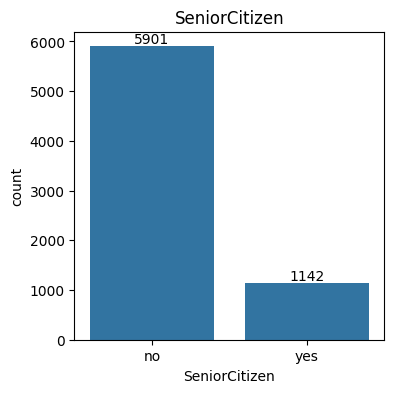

In [68]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x="SeniorCitizen", data = df)
plt.title("SeniorCitizen")
ax.bar_label(ax.containers[0])
plt.show()

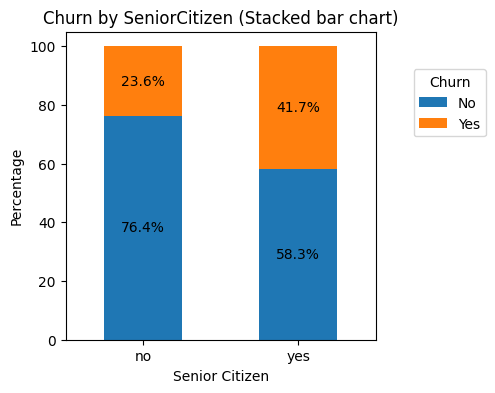

In [87]:
# calculate percentages
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

# plot stacked bar chart
ax = ct.plot(kind="bar", stacked=True, figsize=(4,4))

# add percentage labels on each bar section
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.title("Churn by SeniorCitizen (Stacked bar chart)")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title = "Churn", bbox_to_anchor = (1.10,0.9) )
plt.show()

#churn means leaving the company or ending any relationship with company 
#here, seniorcitizens have higher churn % than non-seniorcitizens 
#it shows that seniorcitizens are more likely to leave
so from my POV 2 solutions are visible here:
1. as senior citizens are more likely to leave so comapny should focus on them by any offers specifically for senior citizens, do this to reduce churn rate.
2. comapny can also do one more thing simply leave the more focus only on senior citizen instead focus on non-seniorcitizens who are not churning as much, do this to maximize revenue by focusing on loyal groups.

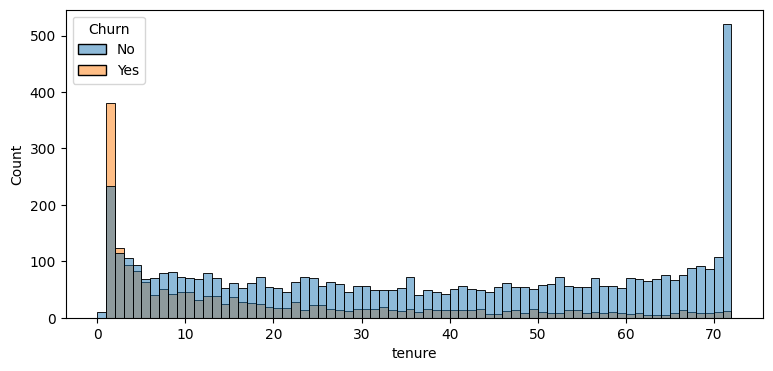

In [96]:
plt.figure(figsize = (9,4))
sns.histplot(x="tenure", data = df, bins = 72 , hue = "Churn")
plt.show()

#tenure means time in which a customer has been with company or time before churning out

#so, it shows that people who have used our services for a long time or our old customers stayed long and didn't churn our quickly and
 new customers or customers who have used or services for around 2 or 3 months have churned out quickly so company should focus on short term reward more than long term reward

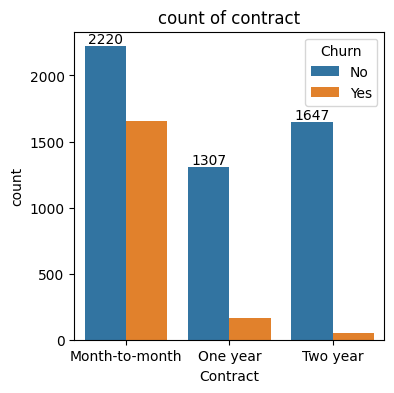

In [99]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x="Contract", data = df, hue = "Churn")
plt.title("count of customers by contract")
ax.bar_label(ax.containers[0])
plt.show()

#people who have Month-to-month	contract are more likely to churn than the people with long term contract like 1 or 2 years
#so campnay should give some offers connected to Month-to-month	contracts like giing discount on upgrade from Month-to-month to yearly contract

In [101]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

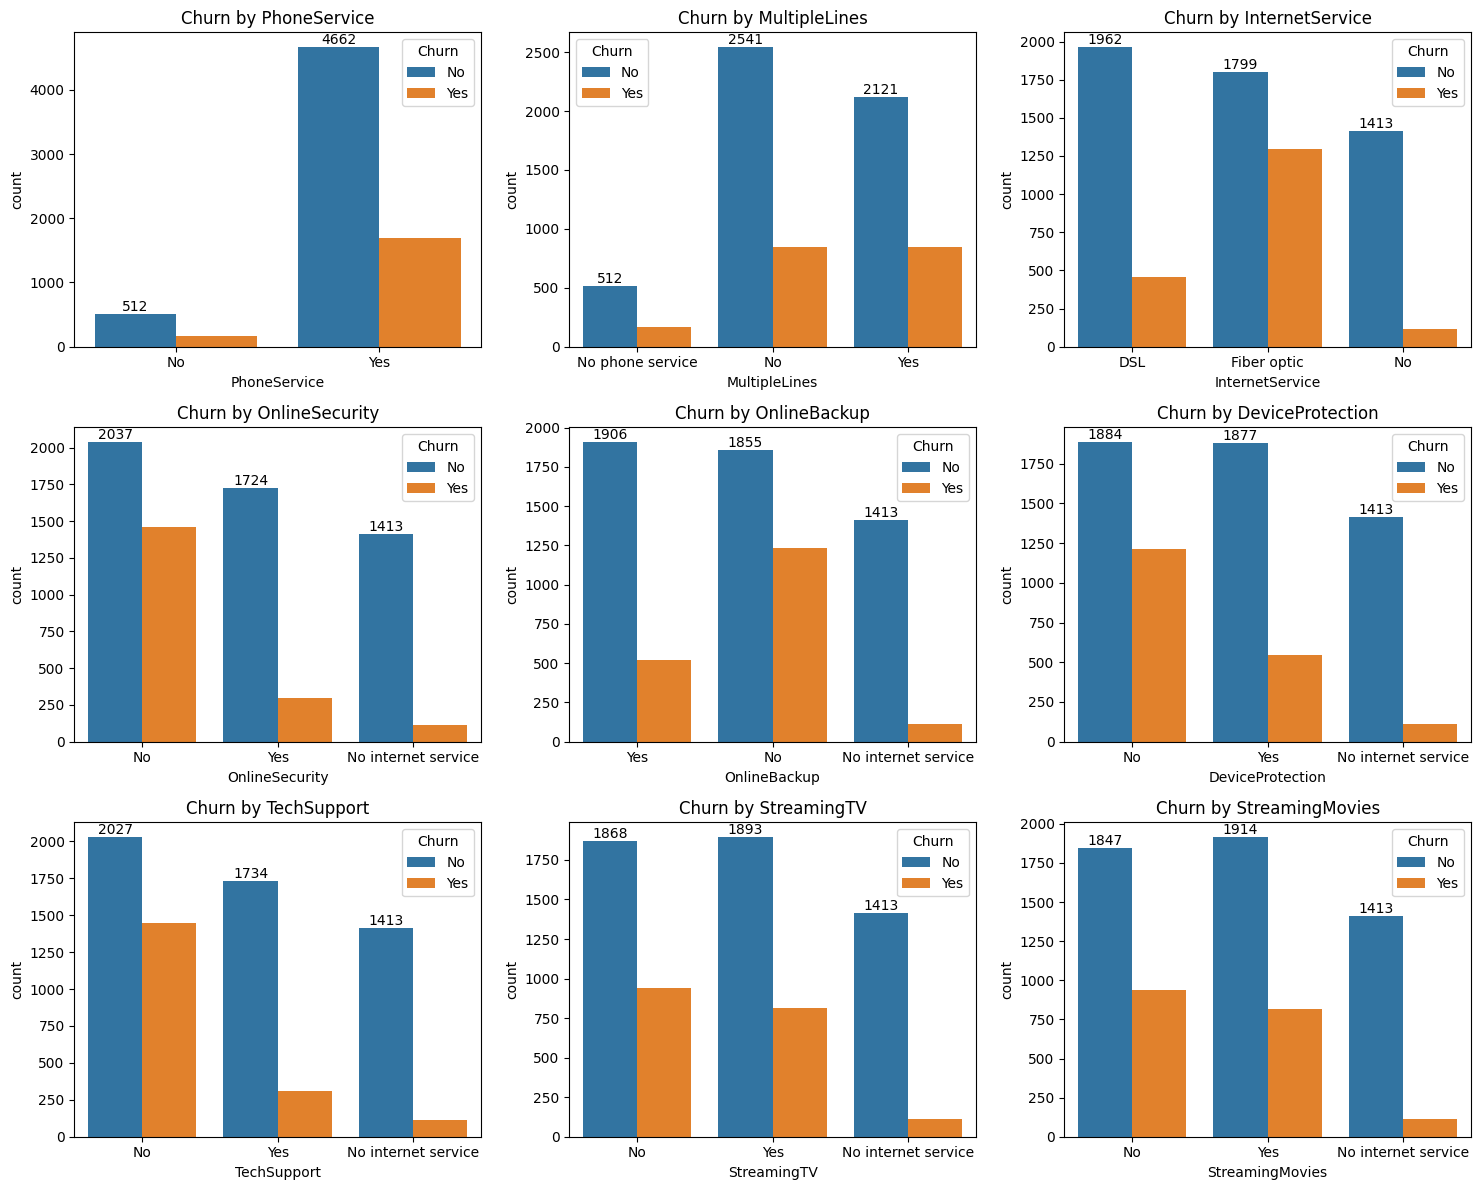

In [110]:
cols = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
        'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue="Churn", ax=axes[i])
    axes[i].set_title(f"Churn by {col}")
    axes[i].bar_label(axes[i].containers[0])

plt.tight_layout()
plt.show()

#Customers without OnlineSecurity, TechSupport, OnlineBackup and DeviceProtection churn significantly more — suggesting customers who don't use protective/support services feel less value in staying. 
Fiber optic internet users churn the most compared to DSL and no internet users — possibly due to higher costs or unmet expectations.
#Streaming services (TV & Movies) show similar churn patterns — having or not having them doesn't make a huge difference in retention.
#Phone service customers are the majority and churn less — meaning core service users are generally more loyal than addon service users.

#One Big Business Recommendation from all this:
Actively promote and possibly offer free trials of OnlineSecurity and TechSupport to new customers — because customers using these services clearly stay longer. Turn addon services into retention tools. 🎯

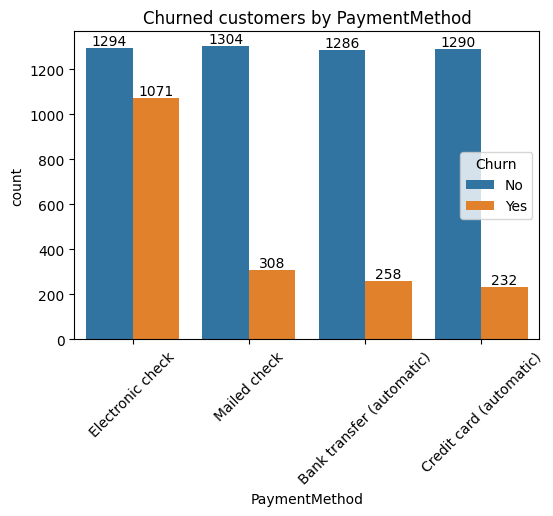

In [131]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x="PaymentMethod", data = df, hue = "Churn")
plt.title("Churned customers by PaymentMethod")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when using electronic check as payement method
Incentivize customers to switch to automatic payment methods — offer a small discount for auto-pay signup. Reduces churn AND improves cash flow. 🎯